# 3장 1강 프로젝트 개요와 문제 정의

## 실습 목표

- Ravenstack의 5개 테이블을 탐색하고 분석 단위와 연결 키를 설명한다.
- 데이터 품질과 기초 분포를 확인하여 분석 가능한 근거를 만든다.
- EDA 결과를 바탕으로 측정 가능한 문제, 목표 지표, 초기 가설을 정의한다.
- 이후 강의에서 검증할 분석 흐름을 일관되게 설계한다.

## 실습 환경 / 데이터

- Python / Colab, `pandas`, `matplotlib`
- `ravenstack_accounts.csv`: 계정 속성과 계정 이탈 여부
- `ravenstack_subscriptions.csv`: 구독 이력과 MRR, 플랜, 이탈 여부
- `ravenstack_feature_usage.csv`: 기능별 사용량과 오류
- `ravenstack_support_tickets.csv`: 문의 처리와 만족도
- `ravenstack_churn_events.csv`: 이탈 사유와 환불

> 분석 기준: 계정의 대표 이탈 지표는 `accounts.churn_flag`로 정의합니다. 서로 다른 테이블의 같은 이름 컬럼을 임의로 섞지 않습니다.

## 실습 준비

### 데이터 불러오기

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

file_names = {
    "accounts": "ravenstack_accounts.csv",
    "subscriptions": "ravenstack_subscriptions.csv",
    "feature_usage": "ravenstack_feature_usage.csv",
    "support_tickets": "ravenstack_support_tickets.csv",
    "churn_events": "ravenstack_churn_events.csv",
}

candidate_dirs = [Path("."), Path("upload"), Path("/content")]
data_dir = next((d for d in candidate_dirs if all((d / f).exists() for f in file_names.values())), None)
if data_dir is None:
    raise FileNotFoundError("5개 CSV를 노트북과 같은 폴더(또는 /content)에 업로드해 주세요.")

data = {name: pd.read_csv(data_dir / file) for name, file in file_names.items()}
accounts = data["accounts"]
subscriptions = data["subscriptions"]
feature_usage = data["feature_usage"]
support_tickets = data["support_tickets"]
churn_events = data["churn_events"]

print("데이터 폴더:", data_dir.resolve())
for name, df in data.items():
    print(f"{name:16s}: {df.shape[0]:,}행 × {df.shape[1]}열")

데이터 폴더: C:\product-analysis-MoonYoungHeum
accounts        : 500행 × 10열
subscriptions   : 5,000행 × 14열
feature_usage   : 25,000행 × 8열
support_tickets : 2,000행 × 9열
churn_events    : 600행 × 9열


### 분석 대상 컬럼 확인

각 테이블의 앞부분과 컬럼을 확인하세요.

In [2]:
for name, df in data.items():
    print(f"\n[{name}] 컬럼")
    print(df.columns.tolist())
    display(df.head(2))


[accounts] 컬럼
['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True



[subscriptions] 컬럼
['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True



[feature_usage] 컬럼
['usage_id', 'subscription_id', 'usage_date', 'feature_name', 'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature']


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False



[support_tickets] 컬럼
['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']


,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False



[churn_events] 컬럼
['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN


### 결측치 및 자료형 확인

날짜 컬럼을 변환하고 키 중복을 확인합니다.

In [3]:
# 날짜 컬럼을 datetime으로 변환합니다.
date_columns = {
    "accounts": ["signup_date"],
    "subscriptions": ["start_date", "end_date"],
    "feature_usage": ["usage_date"],
    "support_tickets": ["submitted_at", "closed_at"],
    "churn_events": ["churn_date"],
}
for name, columns in date_columns.items():
    for column in columns:
        data[name][column] = pd.to_datetime(data[name][column], errors="coerce")

# 분석 단위와 키를 확인합니다.
key_columns = {
    "accounts": "account_id",
    "subscriptions": "subscription_id",
    "feature_usage": "usage_id",
    "support_tickets": "ticket_id",
    "churn_events": "churn_event_id",
}
for name, key in key_columns.items():
    df = data[name]
    print(f"{name:16s} | key 중복 {df[key].duplicated().sum():>2} | 전체 행 중복 {df.duplicated().sum():>2}")

accounts         | key 중복  0 | 전체 행 중복  0
subscriptions    | key 중복  0 | 전체 행 중복  0
feature_usage    | key 중복 21 | 전체 행 중복  0
support_tickets  | key 중복  0 | 전체 행 중복  0
churn_events     | key 중복  0 | 전체 행 중복  0


### 기초 통계량과 분포 확인

아래 코드로 수치형 변수와 주요 범주의 분포를 확인하세요.

In [4]:
display(accounts[["seats", "churn_flag"]].describe())
display(accounts["plan_tier"].value_counts().rename("accounts"))
display(churn_events["reason_code"].value_counts().rename("events"))

,seats
count,500.000000
mean,20.560000
std,21.044718
min,1.000000
25%,5.000000
50%,15.000000
75%,28.000000
max,163.000000


plan_tier
Pro           178
Basic         168
Enterprise    154
Name: accounts, dtype: int64

reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: events, dtype: int64

---

## 필수 1 — 5개 테이블의 EDA 요약

각 테이블에 대해 다음 항목을 하나의 요약표로 만드세요.

1. 행 수와 열 수
2. 전체 결측치 수
3. 완전히 동일한 중복 행 수
4. 날짜 범위(최솟값~최댓값)

그 후 다음 질문에 답하세요.

- 결측치가 있는 테이블과 컬럼은 무엇인가요?
- 결측치를 곧바로 삭제하면 안 되는 이유는 무엇인가요?
- 분석 전에 주의할 데이터 품질 문제를 한 가지 쓰세요.

In [5]:
# TODO: 테이블별 EDA 요약표를 만드세요.
summary_rows = []

# 여기에 코드를 작성하세요.
for name, df in data.items():
    n_rows, n_columns = df.shape
    n_missings = int(df.isnull().sum().sum())
    n_duplicates = int(df.duplicated().sum())
    date_column = date_columns.get(name, [])
    n_min = [df[c].min() for c in date_column]
    n_max = [df[c].max() for c in date_column]
    date_range = f"{min(n_min).date()} ~ {max(n_max).date()}"
    summary_rows.append({
        'table': name,
        'rows': n_rows,
        'cols': n_columns,
        'missing': n_missings,
        'duplicated_rows': n_duplicates,
        'date_range': date_range
    })

eda_summary = pd.DataFrame(summary_rows)
display(eda_summary)

,table,rows,cols,missing,duplicated_rows,date_range
0,accounts,500,10,0,0,2023-01-02 ~ 2024-12-31
1,subscriptions,5000,14,4514,0,2023-01-09 ~ 2024-12-31
2,feature_usage,25000,8,0,0,2023-01-01 ~ 2024-12-31
3,support_tickets,2000,9,825,0,2023-01-02 ~ 2024-12-31
4,churn_events,600,9,148,0,2023-01-25 ~ 2024-12-31


- 결측치가 있는 테이블과 컬럼: subscriptions의 end_date, support_tickets의 satisfaction_score, churn_events의 feedback_text다.
- 결측치를 곧바로 삭제하면 안 되는 이유: 각 결측이 의미가 다르다. end_date가 비어있는 건 구독이 아직 끝나지 않고 현재 활성 상태라는 뜻이라서, 이걸 지우면 지금 살아있는 구독을 통째로 날리는 것과 같다. satisfaction_score가 비어있는 건 고객이 만족도 점수를 응답하지 않았다는 뜻이라서, 이 티켓 자체가 없던 일이 되는 게 아니다. feedback_text가 비어있는 건 이탈하면서 피드백을 남기지 않은 것뿐이지 이탈 사건 자체는 실제로 있었다.
- 분석 전에 주의할 데이터 품질 문제: feature_usage의 usage_id에 중복이 21건 있는데, 이걸 그냥 지우면 실제 발생한 사용 기록을 잃을 수 있어서 왜 중복이 생겼는지 먼저 확인해야 한다.

---

## 필수 2 — 근거를 연결해 분석 문제 정의하기

계정 테이블을 기준으로 다음을 분석하세요.

1. 전체 계정 이탈률을 계산하세요.
2. `industry`, `referral_source`, `is_trial`별 계정 수와 이탈률을 계산하세요.
3. 표본이 20개 이상인 세그먼트 중 전체 이탈률보다 높은 구간을 찾으세요.
4. 결과를 근거로 **문제 정의 1문장**, **현재 지표**, **목표 지표**를 작성하세요.
5. 이탈률이 가장 높은 산업군을 막대그래프로 비교하세요.

> 목표값은 정답이 하나가 아닙니다. 현재 값보다 개선된 수치이며, 지표·대상·기간(또는 평가 시점)이 드러나게 작성하세요.

In [8]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호(-)가 깨지는 것 방지

전체 이탈률: 22.00%


{'industry':                accounts_count  churn_rate  churn_rate_pct
 industry                                                 
 DevTools                  113    0.309735           30.97
 FinTech                   112    0.223214           22.32
 HealthTech                 96    0.218750           21.88
 EdTech                     79    0.164557           16.46
 Cybersecurity             100    0.160000           16.00}

{'industry':                accounts_count  churn_rate  churn_rate_pct
 industry                                                 
 DevTools                  113    0.309735           30.97
 FinTech                   112    0.223214           22.32
 HealthTech                 96    0.218750           21.88
 EdTech                     79    0.164557           16.46
 Cybersecurity             100    0.160000           16.00,
 'referral_source':                  accounts_count  churn_rate  churn_rate_pct
 referral_source                                            
 event                        96    0.302083           30.21
 other                       103    0.242718           24.27
 ads                          98    0.234694           23.47
 organic                     114    0.175439           17.54
 partner                      89    0.146067           14.61}

{'industry':                accounts_count  churn_rate  churn_rate_pct
 industry                                                 
 DevTools                  113    0.309735           30.97
 FinTech                   112    0.223214           22.32
 HealthTech                 96    0.218750           21.88
 EdTech                     79    0.164557           16.46
 Cybersecurity             100    0.160000           16.00,
 'referral_source':                  accounts_count  churn_rate  churn_rate_pct
 referral_source                                            
 event                        96    0.302083           30.21
 other                       103    0.242718           24.27
 ads                          98    0.234694           23.47
 organic                     114    0.175439           17.54
 partner                      89    0.146067           14.61,
 'is_trial':           accounts_count  churn_rate  churn_rate_pct
 is_trial                                            
 True  


[['churn_date']]


,accounts_count,churn_rate,churn_rate_pct
industry,,,
DevTools,113,0.309735,30.97
FinTech,112,0.223214,22.32



[['churn_date']]


,accounts_count,churn_rate,churn_rate_pct
referral_source,,,
event,96,0.302083,30.21
other,103,0.242718,24.27
ads,98,0.234694,23.47



[['churn_date']]


,accounts_count,churn_rate,churn_rate_pct
is_trial,,,
True,97,0.257732,25.77


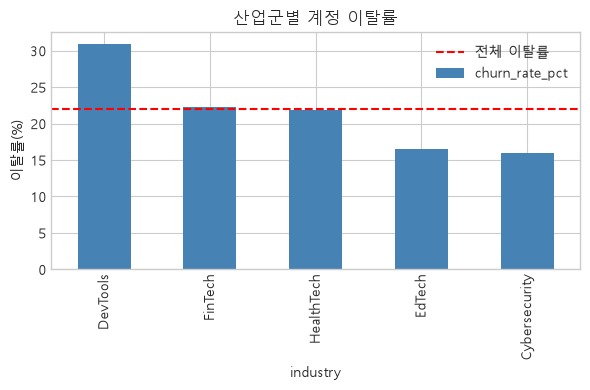

In [9]:
# TODO: 전체 및 세그먼트별 이탈률을 계산하세요.
overall_churn_rate = accounts['churn_flag'].mean()
print(f'전체 이탈률: {overall_churn_rate*100:.2f}%')

segment_results = {}
for column in ["industry", "referral_source", "is_trial"]:
    # 여기에 코드를 작성하세요.
    g = accounts.groupby(column)['churn_flag'].agg(
        accounts_count = 'count',
        churn_rate = 'mean'
    )
    g['churn_rate_pct'] = (g['churn_rate'] * 100).round(2)
    segment_results[column] = g.sort_values('churn_rate', ascending=False)
    display(segment_results)

for column, g in segment_results.items():
    high = g[(g['accounts_count'] >= 20) & (g['churn_rate'] > overall_churn_rate)]
    if len(high):
        print(f'\n[{columns}]')
        display(high)
    
# TODO: 산업별 이탈률 그래프를 그리세요.
industry_churn = segment_results["industry"]["churn_rate_pct"]
industry_churn.plot(kind="bar", color="steelblue", figsize=(6, 4))
plt.axhline(overall_churn_rate * 100, color="red", linestyle="--", label="전체 이탈률")
plt.ylabel("이탈률(%)")
plt.title("산업군별 계정 이탈률")
plt.legend()
plt.tight_layout()
plt.show()

### 필수 2 서술 답안

- 발견한 핵심 패턴: 전체 이탈률은 22.00%인데, industry가 DevTools인 계정은 30.97%로 가장 높고, referral_source가 event인 계정도 30.21%로 비슷하게 높다. 두 세그먼트 모두 표본이 90개 이상으로 충분히 크다.
- 문제 정의: DevTools 산업군 계정의 이탈률(30.97%)이 전체 평균(22.00%)보다 약 9%p 높아, 이 세그먼트에서 이탈이 상대적으로 집중되고 있다.
- 현재 지표: DevTools 산업군 계정 이탈률 30.97%
- 목표 지표: 다음 2개 분기 안에 DevTools 산업군 계정 이탈률을 전체 평균 수준인 22.00% 이하로 낮춘다.
- 목표 지표가 적절한 이유: 이미 확보된 표본으로 산출된 실측값을 기준으로 하고, 비교 대상(전체 평균)이 같은 데이터에서 나온 값이라 임의로 정한 수치가 아니다. 대상과 기간이 명확해서 이후 개선 여부를 같은 방식으로 다시 측정해 확인할 수 있다.

---

## 과제 1 — 이탈 원인 가설과 검증 계획 세우기

필수 2에서 정의한 문제를 바탕으로 초기 가설 3개를 작성하세요.

- 적어도 2개는 현재 제공된 데이터로 검증 가능해야 합니다.
- 각 가설에 `필요한 테이블·컬럼`, `확인할 비교 또는 지표`, `우선순위`를 적으세요.
- 가장 먼저 검증할 가설 1개를 고르고 이유를 설명하세요.
- 2강 분석 → 3강 실험 → 4강 제안이 처음 문제와 어떻게 연결되는지 한 문장씩 작성하세요.

| 우선순위 | 가설 | 필요한 데이터 | 검증 방법 |
|---:|---|---|---|
| 1 |DevTools 계정은 다른 산업군보다 지원 티켓 만족도가 낮아서 이탈로 이어졌을 것이다  |support_tickets.satisfaction_score, accounts.industry  |DevTools 계정과 다른 산업군 계정의 만족도 비교  |
| 2 |DevTools 계정은 요금제 하향 이후 이탈로 이어지는 비율이 더 높을 것이다  |subscriptions.downgrade_flag, churn_flag, accounts.industry  |요금제 하향을 겪지 않은 계정과 겪은 계정의 이탈률을 산업군별로 비교  |
| 3 |DevTools 계정은 다른 산업군보다 핵심 기능 사용량이 적어 이탈로 이어졌을 것이다  |feature_usage.usage_count, accounts.industry  |DevTools 계정과 다른 산업군 계정의 평균 기능 사용량 비교  |

### 프로젝트 연결
- 1번과 연결하였음
- 2강 분석: DevTools 계정의 지원 티켓 만족도, 다운그레이드 이력, 기능 사용량을 다른 산업군과 비교 분석하여 이탈과 가장 관련 있는 요인을 설정한다.
- 3강 실험: 2강에서 찾은 요인을 개선한 버전을 DevTools 계정 일부에 적용해 A/B 테스트로 효과를 검증한다.
- 4강 제안: 실험에서 효과가 확인된 개선안을 DevTools 산업군 전체에 적용할지, 어떤 조건에서 적용할지 제안하고 목표 지표 달성 여부를 확인한다.

---

## 실습 마무리

- 어떤 분석 문제가 있었는가? Ravenstack 전체 계정 이탈률(22.00%)보다 특정 세그먼트의 이탈률이 눈에 띄게 높다는 문제였다.
- 어떤 통계적·분석적 방법을 적용했는가? 5개 테이블의 구조·결측치·중복을 확인하는 EDA와, industry·referral_source·is_trial 기준의 세그멘테이션 분석을 적용했다.
- 무엇을 근거로 결론을 내렸는가? 표본 크기가 20개 이상으로 충분하면서 전체 평균(22.00%)보다 이탈률이 높은 세그먼트를 실제 계산된 수치로 확인한 뒤, 그중 표본이 가장 크고 격차가 큰 DevTools를 우선 점검 대상으로 정했다.